In [ ]:
import scanpy as sc
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np

adata = sc.read_h5ad("xenium5k_scVI_CellCharter_batch2_reannot.h5ad")
path = " " #path to folder for saving figures

In [3]:
adata

AnnData object with n_obs × n_vars = 2131098 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden', 'megagut_lvl3_predicted_labels', 'megagut_lvl3_over_clustering', 'megagut_lvl3_majority_voting', 'megagut_lvl3_conf_score', 'megagut_lvl1_predicted_labels', 'megagut_lvl1_over_clustering', 'megagut_lvl1_majority_voting', 'megagut_lvl1_conf_score', 'fibro_predicted_labels', 'fibro_over_clustering', 'fibro_majority_voting', 'fibro_conf_score', 'MF1_prob', 'MF2_prob', 'PC_prob', 'S1_prob', 'S2_prob', 'S3_prob', 'S3x_prob', 'S4_prob',

In [4]:
adata = adata[adata.obs.transcript_counts >= 100]

In [5]:
cluster = adata.obs['spatial_cluster15']
sample = adata.obs["sample"]
celltype = adata.obs["annot_new"]

sample_niche_celltype = pd.DataFrame({
    "sample": sample,
    "spatial_cluster15": cluster,
    "annot_new": celltype,
})

sample_niche_celltype


,sample,spatial_cluster15,annot_new
0054175__GI10072_CD_adj_aaaaanid-1,0054175__GI10072_CD_adj,8,Mast
0054175__GI10072_CD_adj_aaaabcgc-1,0054175__GI10072_CD_adj,8,T_CD8_TE_Cycling
0054175__GI10072_CD_adj_aaaadecm-1,0054175__GI10072_CD_adj,8,NaN
0054175__GI10072_CD_adj_aaaajilg-1,0054175__GI10072_CD_adj,3,Glial cell
0054175__GI10072_CD_adj_aaacmgpn-1,0054175__GI10072_CD_adj,3,Glial cell
...,...,...,...
0043587_affected_oimglgpc-1,0043587_affected,9,NaN
0043587_affected_oimlffha-1,0043587_affected,9,Glial cell
0043587_affected_oimlghpj-1,0043587_affected,9,SM GREM1hi fibrotic muscle
0043587_affected_oimoklkm-1,0043587_affected,9,Macrophage


In [6]:
len(adata.obs["annot_new"].cat.categories)

62

In [7]:
inf = ['0033516_affected','0043587_affected','0054175__GI_10072_CD_inf','0054433__GI9676_CD_inf','0072732__CD10500INF','0072926__CD9623INF','0060032__gi9662_inf','0060032__gi10056_inf']

not_inf = ['0033516_adjacent', '0043587_adjacent','0054175__GI10072_CD_adj','0054433__GI9676_CD_adj', '0060032__gi9662_nor', '0060032__gi10056_nor',
       '0072732__CD10500NOR', '0072926__CD9623NOR']

In [8]:
def get_niche(df, niche):
    niche_table = df.copy()
    niche_table = niche_table[niche_table["spatial_cluster15"]==f"{niche}"]
    return niche_table

In [9]:
compartments_sub = {
        #LYMPHOID
        'B_memory':"B",'B_plasma_IgA1':"B", 'B_germinal center':"B",
        'TH_17':"T", 'TH_17_Cycling':"T",'T_CD4_CM':"T", 'T_CD4_Cycling':"T", 'T_CD4_EM':"T", 'T_CD8_EM':"T", 'T_CD8_RM':"T",'T_CD8_TE':"T",'T_CD8_TE_Cycling':"T", 'T_CD8_CM':"T",'T_G/D':"T", 'T_Reg':"T", 'T_FH':"T", 'T_mixed':"T",

        #NEURAL
        'Neuron':"Neural", 'Glial cell':"Neural",

        #MYELOID
        'CLEC9Ahi DC':"DC", 'CCL19hi DC':"DC",'DC_pDC':"DC", 

        'Macrophage':"Macrophage", 'CD14hi macrophage':"Macrophage", 'B cell-adjacent macrophage':"Macrophage", 'CXCL9 macrophage':"Macrophage",'CXCL12 macrophage':"Macrophage",
        'Neuron-associated macrophage':"Macrophage", 'Phagocytic macrophage':"Macrophage", 'SMC-associated macrophage':"Macrophage", 'Subepithelial macrophage':"Macrophage", 

        'Mast':"Mast", 'Monocyte':"Monocyte", 

        #ENDOTHELIUM
        'Lymphatic endothelium':"Endothelial", 'SELPhi endothelium':"Endothelial", 'EC arterial':"Endothelial", 'EC capillary':"Endothelial", 
        'EC lymphatic':"Endothelial", 'EC veneous_1':"Endothelial",'EC veneous_2':"Endothelial", 'Epithelial_stem':"Endothelial",
        
        #EPITHELIUM
        'Absorptive enterocyte':"Epithelial",'transit amplifying epithelium':"Epithelial", 'Goblet cell':"Epithelial", 'MUC5B goblet':"Epithelial", 
        
        #STROMAL
        'CMP GREM1hi muscle':"Muscular", 'SM GREM1hi fibrotic muscle':"Muscular", 'MM NR4A1hi muscle':"Muscular", 'LMP NR4A1hi muscle':"Muscular", 'CMP SYNMhi muscle':"Muscular",
        'SM MCAMhi perivascular muscle':"Muscular",

        'M ADAMDEChi fibroblast':"Fibroblast", 'M COL4A1hi pericryptal fibroblast':"Fibroblast", 'S SOCS3hi fibroblast':"Fibroblast", 'MP DPThi fibroblast':"Fibroblast", 
        'SM GREM1hi fibroblast':"Fibroblast",'SM TNChi fibrotic myofibroblast':"Fibroblast", 'SM CA12hi universal fibroblast':"Fibroblast", 'SM PI16hi universal fibroblast':"Fibroblast", 
        'SM CCL19hi FRC-like fibroblast':"Fibroblast", 'M COL7A1hi inflammatory fibroblast':"Fibroblast", 

        'SM&M CCL19hi pericyte':"Pericyte", 'SM&M PDGFRBhi pericyte':"Pericyte"
       
}

compartments = {
    
    #LYMPHOID
    "B":"Lymphoid", "T":"Lymphoid",
    #MYELOID
    "DC":"Myeloid","Macrophage":"Myeloid","Mast":"Myeloid","Monocyte":"Myeloid",
    #ENDOTHELIUM
    "Endothelial":"Endothelial",
    #EPITHELIUM
    "Epithelial":"Epithelial",
    #Neural
    "Neural":"Neural",
    #STROMAL
    "Muscular":"Stromal", "Fibroblast":"Stromal", "Pericyte":"Stromal"

}

comp_cmaps = {
    "Lymphoid": cm.Blues,
    "Myeloid": cm.Greens,
    "Endothelial": cm.Reds,
    "Epithelial": cm.Purples,
    "Neural": cm.Greys,
    "Stromal": cm.Oranges
}

color_comps = {
    #LYMPHOID
    "Lymphoid":['B_memory','B_plasma_IgA1', 'B_germinal center',
        'TH_17', 'TH_17_Cycling','T_CD4_CM', 'T_CD4_Cycling', 'T_CD4_EM', 'T_CD8_EM', 'T_CD8_RM','T_CD8_TE','T_CD8_TE_Cycling', 'T_CD8_CM','T_G/D', 'T_Reg', 'T_FH', 'T_mixed'],

    #MYELOID
    "Myeloid":  ['CLEC9Ahi DC', 'CCL19hi DC', 'DC_pDC', 'Macrophage', 'CD14hi macrophage', 'B cell-adjacent macrophage', 'CXCL9 macrophage','CXCL12 macrophage',
        'Neuron-associated macrophage', 'Phagocytic macrophage', 'SMC-associated macrophage', 'Subepithelial macrophage','Mast', 'Monocyte'],
        
    #ENDOTHELIUM
    "Endothelial":['Lymphatic endothelium', 'SELPhi endothelium', 'EC arterial', 'EC capillary','EC lymphatic', 'EC veneous_1','EC veneous_2', 'Epithelial_stem'],

    #EPITHELIUM
    "Epithelial": ['Absorptive enterocyte', 'transit amplifying epithelium', 'Goblet cell', 'MUC5B goblet'], 

    #Neural
    "Neural": ['Neuron','Glial cell'],

    #STROMAL
    "Stromal": ['CMP GREM1hi muscle', 'SM GREM1hi fibrotic muscle', 'MM NR4A1hi muscle', 'LMP NR4A1hi muscle', 'CMP SYNMhi muscle',
        'SM MCAMhi perivascular muscle','M ADAMDEChi fibroblast', 'M COL4A1hi pericryptal fibroblast', 'S SOCS3hi fibroblast', 'MP DPThi fibroblast', 
        'SM GREM1hi fibroblast','SM TNChi fibrotic myofibroblast', 'SM CA12hi universal fibroblast', 'SM PI16hi universal fibroblast', 
        'SM CCL19hi FRC-like fibroblast', 'M COL7A1hi inflammatory fibroblast',
        'SM&M CCL19hi pericyte', 'SM&M PDGFRBhi pericyte']
       
}

colors = []

for category, celltypes in color_comps.items():
    n = len(celltypes)
    cmap = comp_cmaps[category]

    # Generate N shades for this category
    shades = cmap(np.linspace(0.4, 0.9, n))

    # Assign shades to the correct columns
    for celltype, shade in zip(celltypes, shades):
        colors.append((celltype, shade))

reordered_cells = [celltype for celltype_list in color_comps.values() for celltype in celltype_list]

In [10]:
sample_niche_celltype_compartment = sample_niche_celltype.copy()
sample_niche_celltype_compartment["compartment_sub"] = sample_niche_celltype_compartment["annot_new"].replace(compartments_sub)
sample_niche_celltype_compartment["compartment"] = sample_niche_celltype_compartment["compartment_sub"].map(compartments)
sample_niche_celltype_compartment

/var/folders/5t/yw2vlxtd5szfgwlywgjzn1gc0000gn/T/ipykernel_29036/3811833139.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  sample_niche_celltype_compartment["compartment_sub"] = sample_niche_celltype_compartment["annot_new"].replace(compartments_sub)


,sample,spatial_cluster15,annot_new,compartment_sub,compartment
0054175__GI10072_CD_adj_aaaaanid-1,0054175__GI10072_CD_adj,8,Mast,Mast,Myeloid
0054175__GI10072_CD_adj_aaaabcgc-1,0054175__GI10072_CD_adj,8,T_CD8_TE_Cycling,T,Lymphoid
0054175__GI10072_CD_adj_aaaadecm-1,0054175__GI10072_CD_adj,8,NaN,NaN,NaN
0054175__GI10072_CD_adj_aaaajilg-1,0054175__GI10072_CD_adj,3,Glial cell,Neural,Neural
0054175__GI10072_CD_adj_aaacmgpn-1,0054175__GI10072_CD_adj,3,Glial cell,Neural,Neural
...,...,...,...,...,...
0043587_affected_oimglgpc-1,0043587_affected,9,NaN,NaN,NaN
0043587_affected_oimlffha-1,0043587_affected,9,Glial cell,Neural,Neural
0043587_affected_oimlghpj-1,0043587_affected,9,SM GREM1hi fibrotic muscle,Muscular,Stromal
0043587_affected_oimoklkm-1,0043587_affected,9,Macrophage,Macrophage,Myeloid


In [11]:
sample_niche_celltype_compartment["compartment"].unique()

array(['Myeloid', 'Lymphoid', nan, 'Neural', 'Epithelial', 'Stromal',
       'Endothelial'], dtype=object)

# Functions for generating plots

In [12]:
def subplots_all_celltypes(df=sample_niche_celltype):  

    fig, axes = plt.subplots(4, 4, figsize=(30, 30))

    axes = axes.flatten()

    for niche in range(0,15):
        dataframe = get_niche(df, niche) 
        sample = dataframe["sample"].values
        celltype = dataframe["annot_new"].values

        ax = axes[niche]

        cross = pd.crosstab(sample, celltype, rownames =["sample"], colnames=["annot_new"]) 
        all_samples = df["sample"].unique()
        cross = cross.reindex(all_samples, fill_value=0.0)
        cross = cross.reindex(columns=reordered_cells)

        cross['sum'] = cross.sum(axis=1)
        cross["state"] = ["inf" if s in inf else "not_inf" for s in cross.index]
        cross = cross.sort_values(["state", "sum"], ascending=[True, False], kind="mergesort")
        cross.drop(labels = ["sum","state"], axis=1, inplace=True)

        ordered_colors = [dict(colors)[col] for col in cross.columns]

        cross.plot(kind="bar", ylabel = "Number of cells", stacked=True, color = ordered_colors , ax=ax, legend = False) 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        labels = ax.get_xticklabels()
        plt.setp(labels, rotation=45, rotation_mode='anchor', ha='right', va='top')
        ax.set_xlabel(None)
        ax.set_title(f"Niche {niche}", fontsize=18)
        
    handles, labels = ax.get_legend_handles_labels()
        
    legend_ax = axes[15]
    legend_ax.axis("off")
    legend_ax.legend(handles, labels, loc="best",ncol=2,fontsize="large")

    fig.tight_layout()
    st = fig.suptitle("Cell type composition per sample across niches", fontsize=25)
    st.set_y(0.95)
    fig.subplots_adjust(top=0.90)
    fig.savefig(f"{path}nichediv.pdf",format="pdf",bbox_inches = "tight")

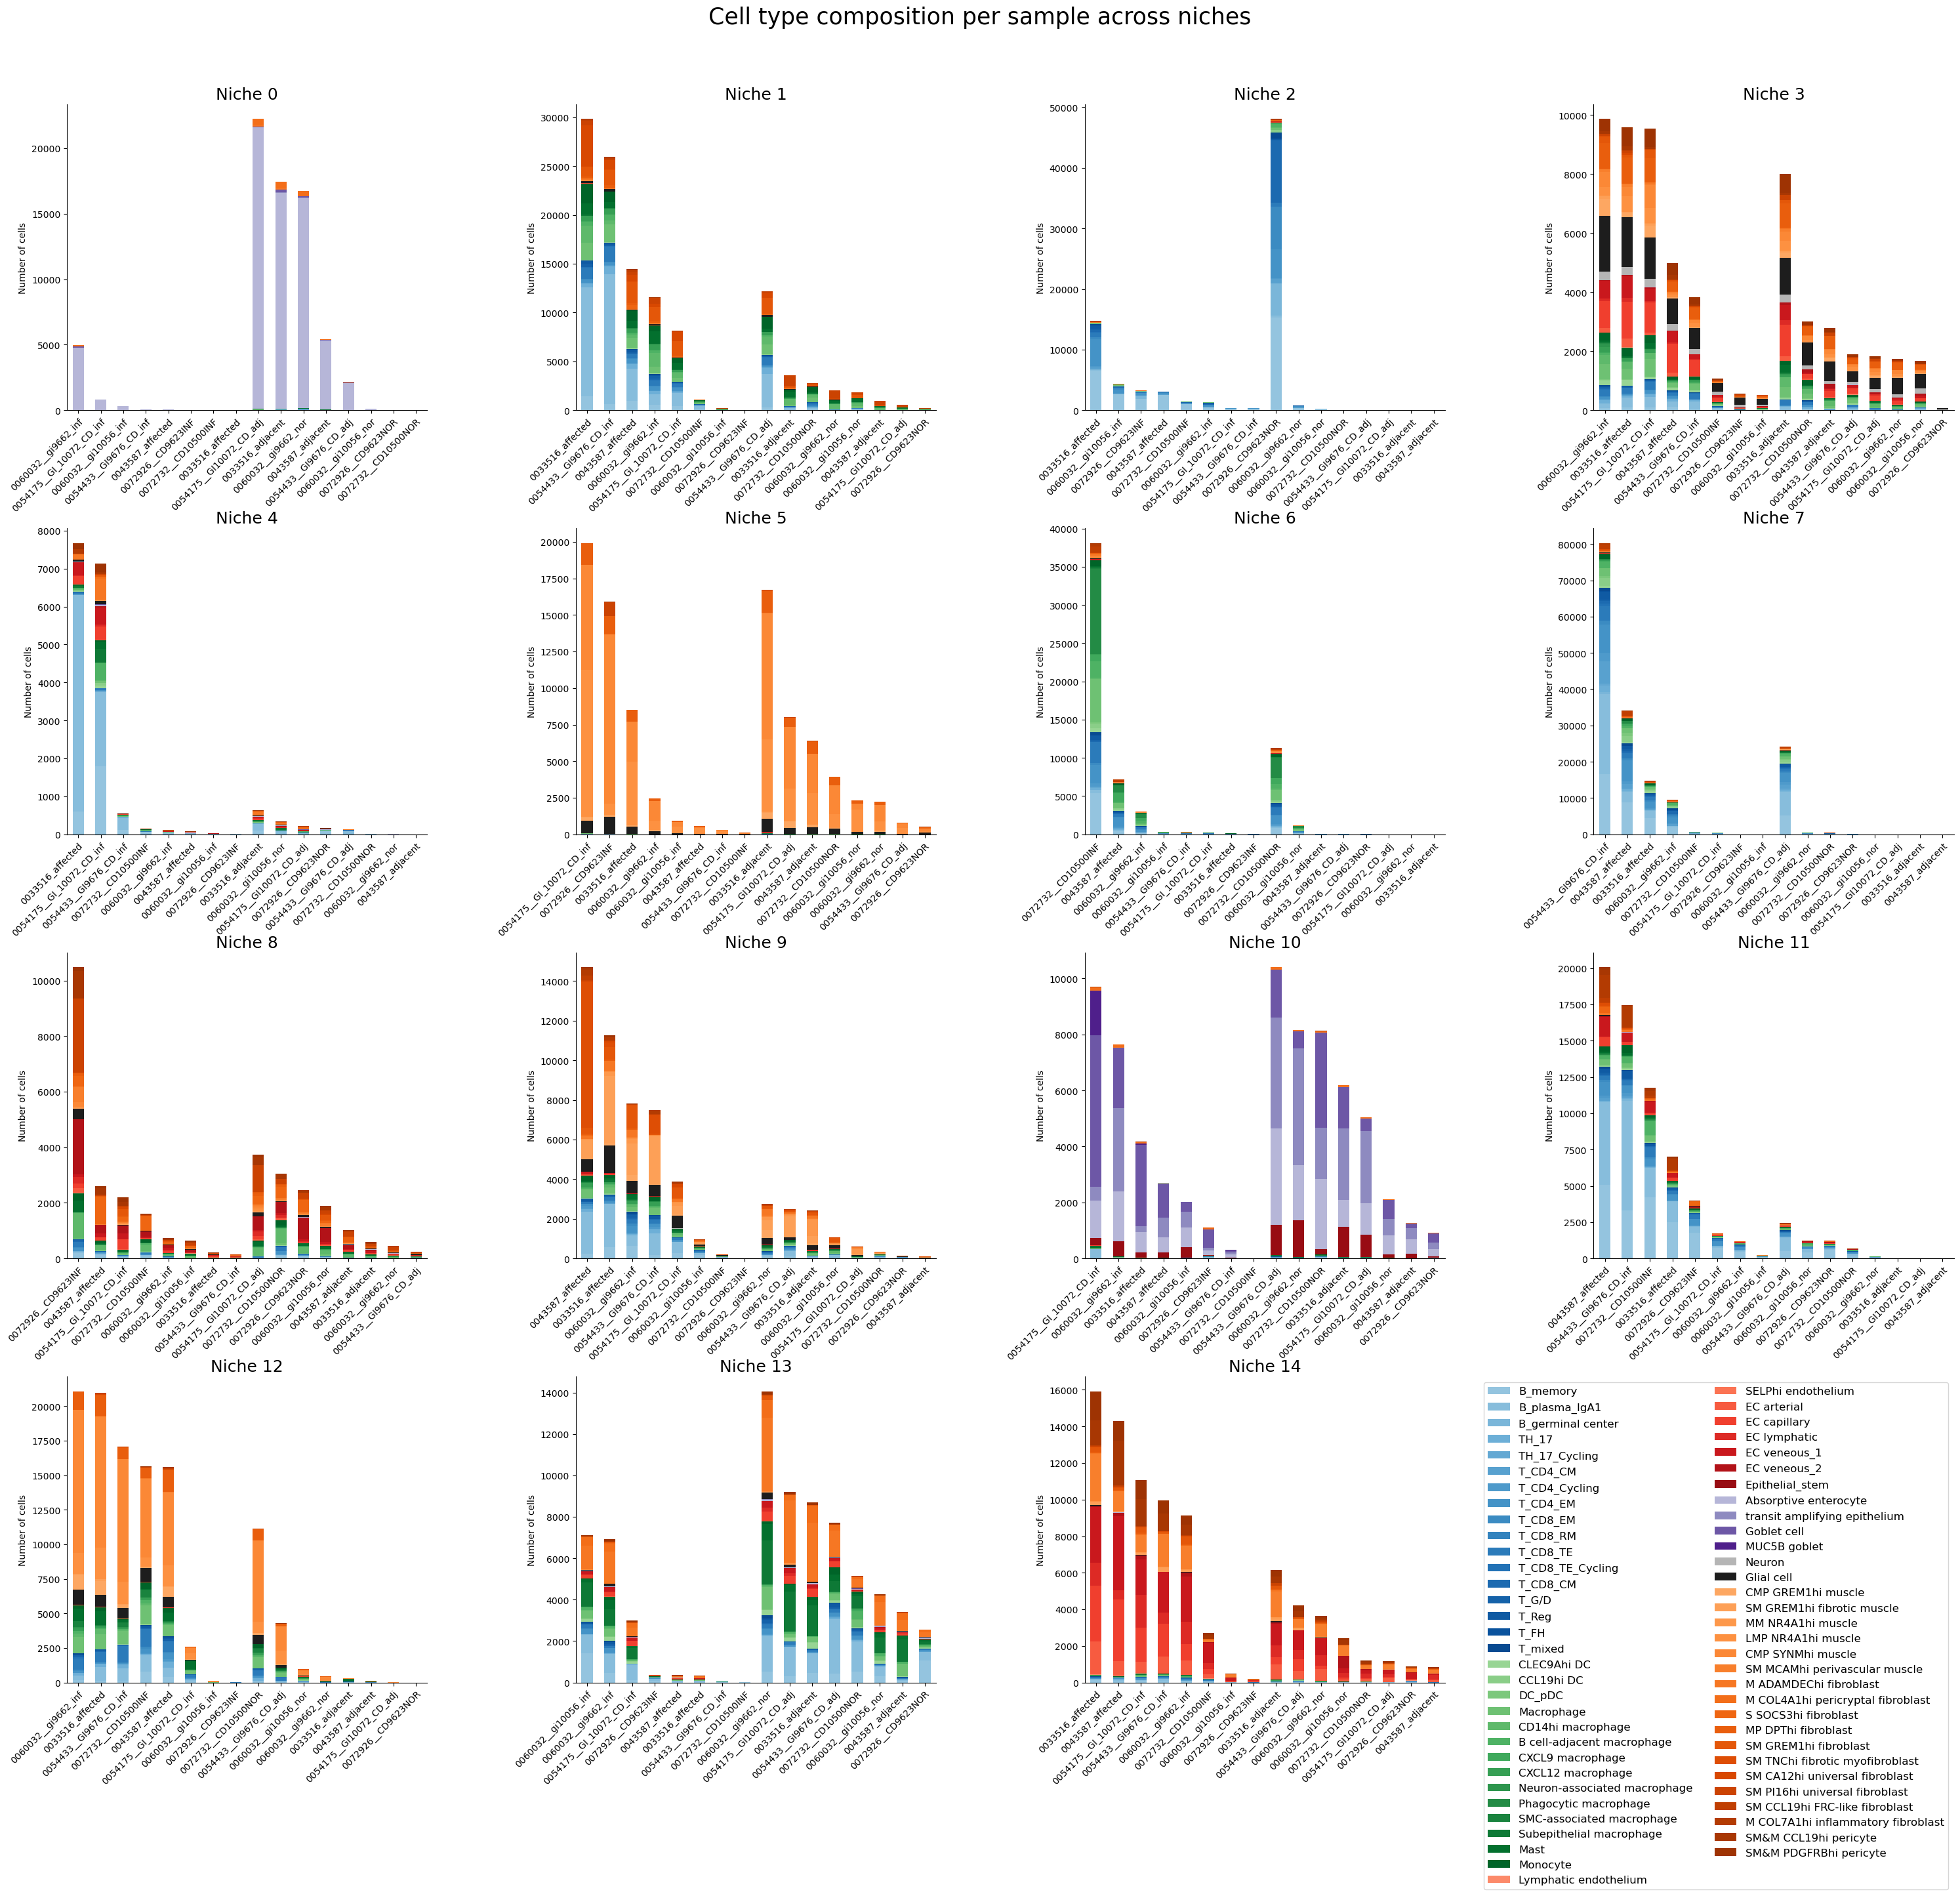

In [13]:
subplots_all_celltypes()

In [14]:
def subplots_cellcompartments(df=sample_niche_celltype_compartment):
    
    fig, axes = plt.subplots(4, 4, figsize=(30, 30))
    axes = axes.flatten()
    
    for niche in range(0,15):
        dataframe = get_niche(sample_niche_celltype_compartment, niche)
        sample = dataframe["sample"].values
        celltype = dataframe["compartment"].values

        ax = axes[niche]

        cross = pd.crosstab(sample, celltype, rownames =["sample"], colnames=["compartment"], normalize = "index")

        all_samples = sample_niche_celltype["sample"].unique()
        cross = cross.reindex(all_samples, fill_value=0.0)
        cross = cross.reindex(columns=["Lymphoid", "Myeloid", "Endothelial", "Epithelial", "Neural", "Stromal"])

        cross["state"] = ["inf" if s in inf else "not_inf" for s in cross.index]
        cross = cross.sort_values(["state"], ascending=[True], kind="mergesort")
        cross.drop(labels = ["state"], axis=1, inplace=True)

        n = 0.6
        colors = [cm.Blues(n), cm.Greens(n), cm.Reds(n), cm.Purples(n+0.1), cm.Greys(n), cm.Oranges(n-0.15)]
        
        cross.plot(kind="bar", ylabel = "Proportional composition", stacked=True, ax=ax, legend = False, color=colors) 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        labels = ax.get_xticklabels()
        plt.setp(labels, rotation=45, rotation_mode='anchor', ha='right', va='top')
        ax.set_xlabel(None)
        ax.set_title(f"Niche {niche}", fontsize=18, pad = -50)
        
    handles, labels = ax.get_legend_handles_labels()
        
    legend_ax = axes[15]
    legend_ax.axis("off")
    legend_ax.legend(handles, labels, loc="center",fontsize="xx-large")

    fig.tight_layout()
    st = fig.suptitle("Cell compartment composition per sample across niches", fontsize=25)
    st.set_y(0.95)
    fig.subplots_adjust(top=0.90)

    fig.savefig(f"{path}Compartments_norm.pdf",format="pdf",bbox_inches = "tight")

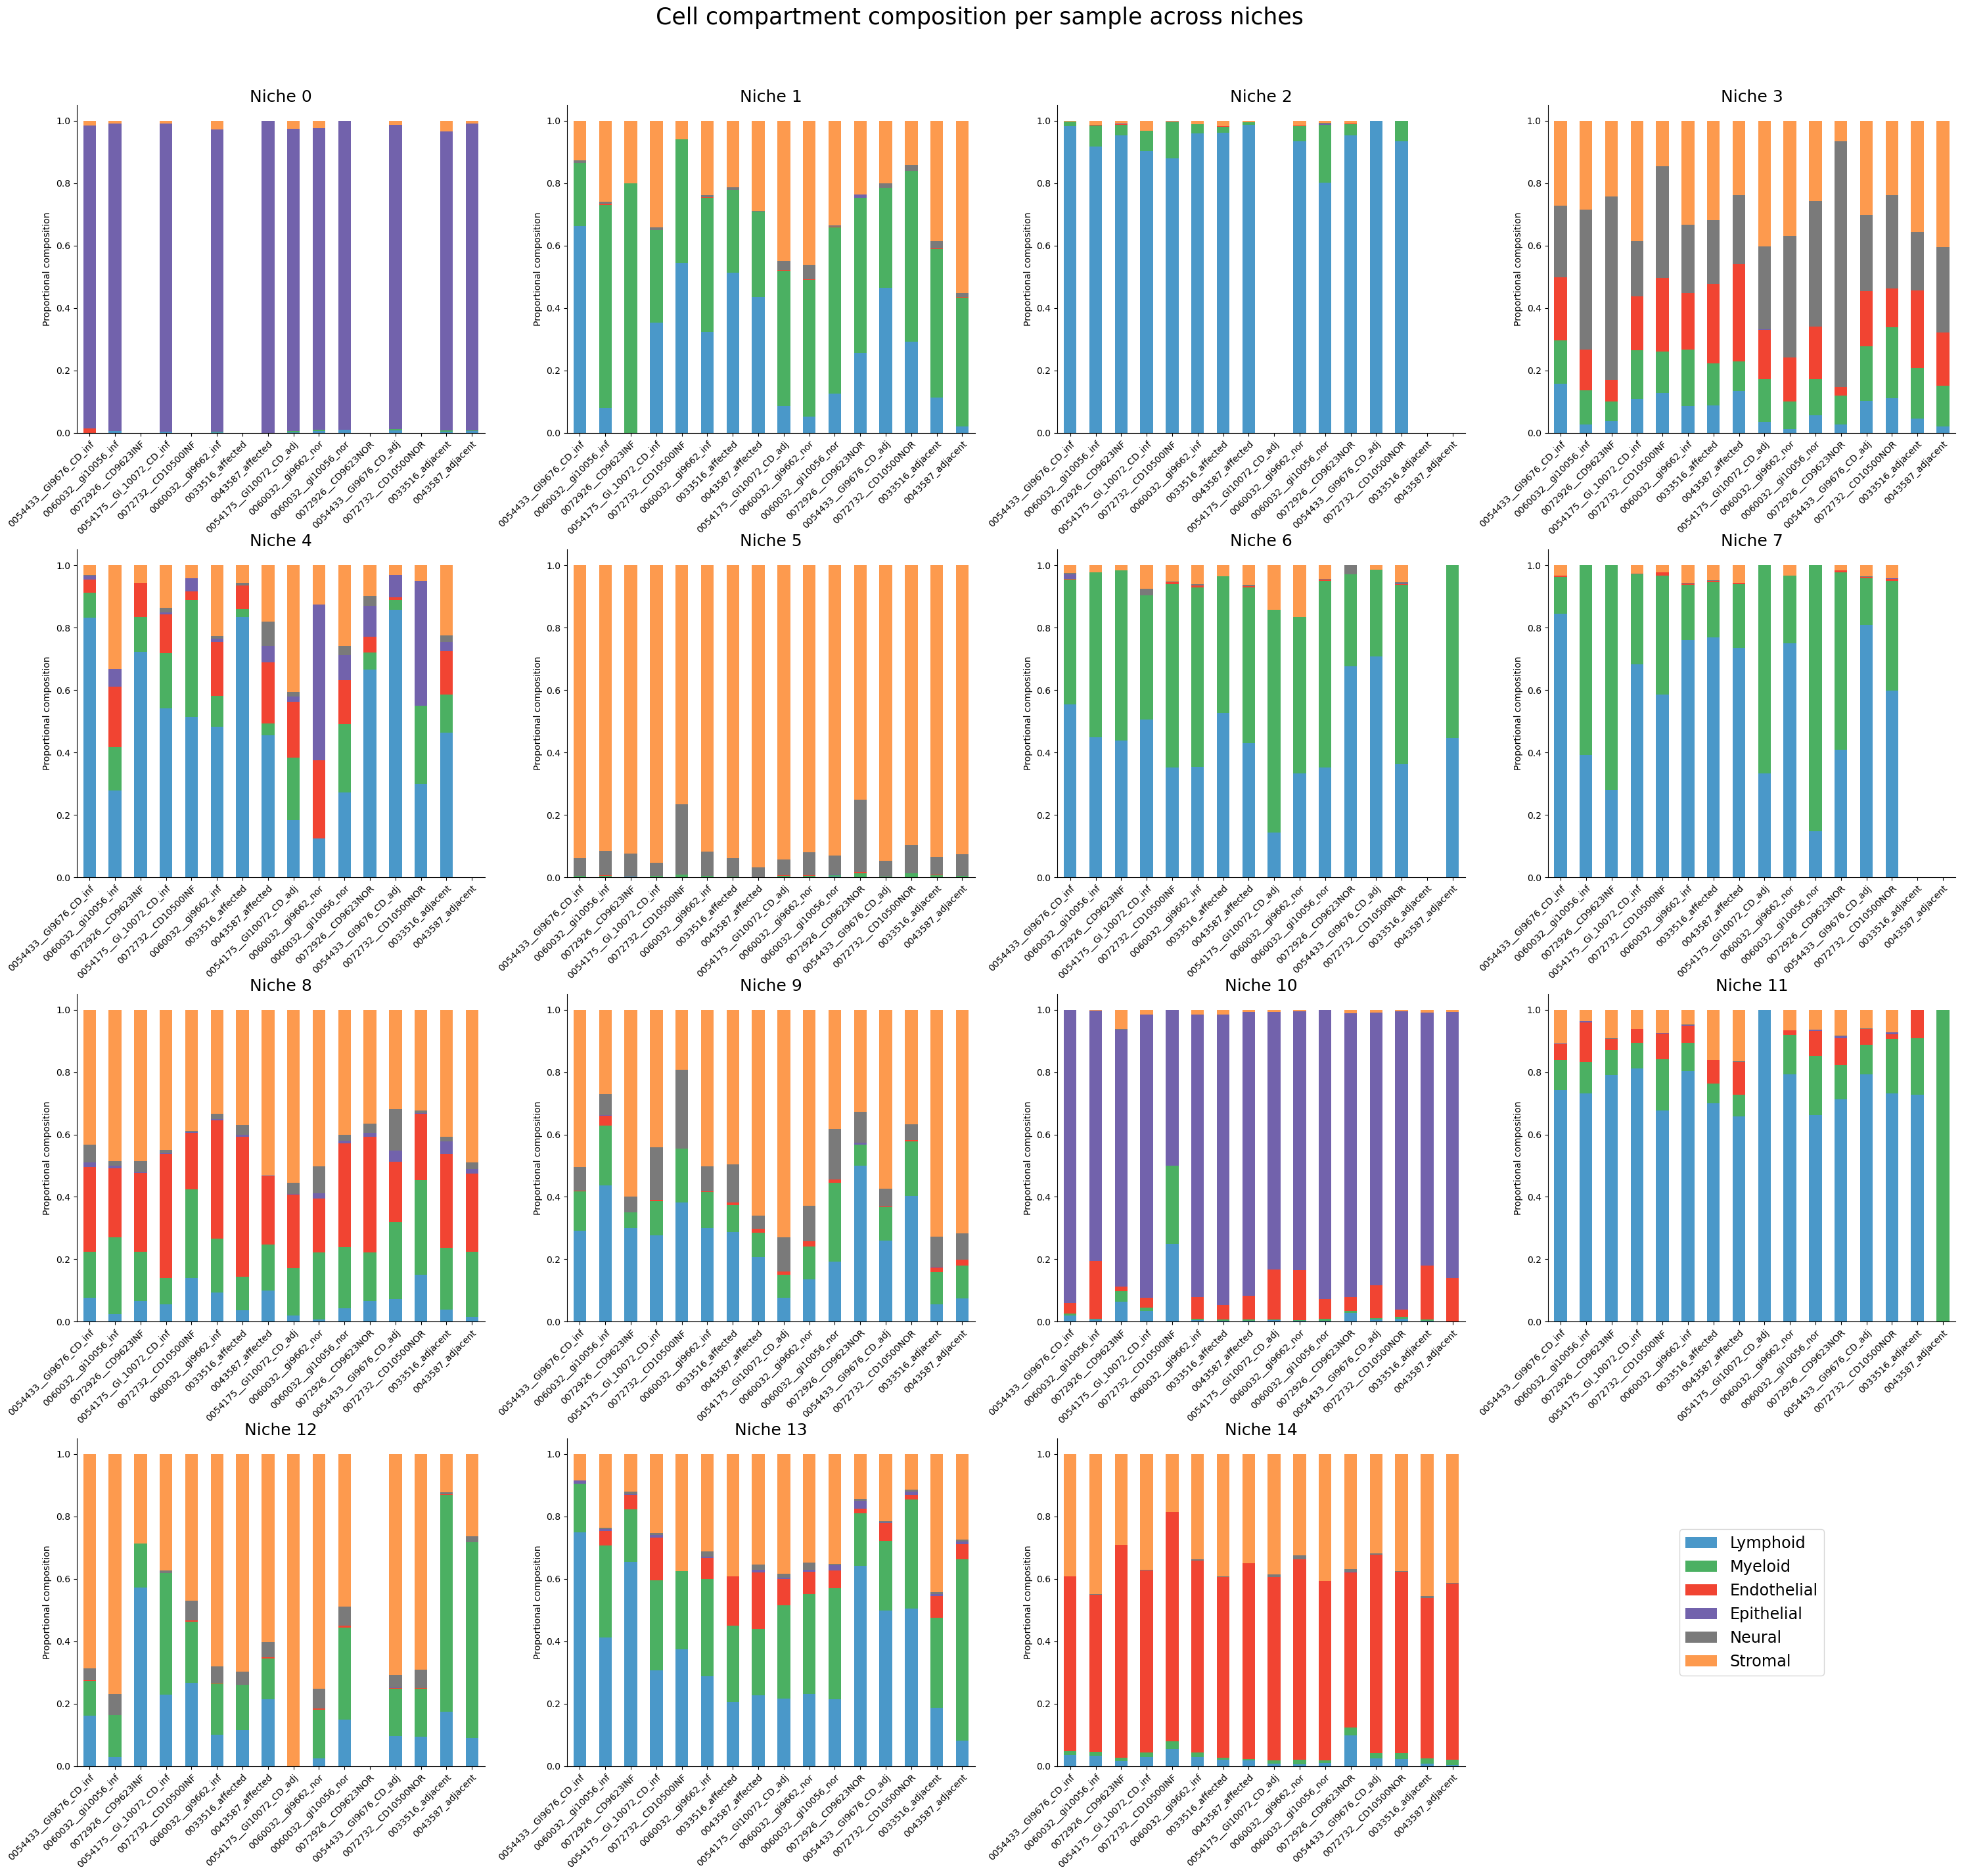

In [15]:
subplots_cellcompartments()

In [16]:
def subplots_celltypes(compartment_sub_list, cell_order=None, df=sample_niche_celltype_compartment):
    
    compartment = df[df["compartment_sub"].isin(compartment_sub_list)]
    fig, axes = plt.subplots(4, 4, figsize=(30, 30))
    axes = axes.flatten()

    for niche in range(0,15):
                
        dataframe = get_niche(compartment, niche)
        sample = dataframe["sample"].values
        celltype = dataframe["annot_new"].values

        ax = axes[niche]

        cross = pd.crosstab(sample, celltype, rownames =["sample"], colnames=["annot_new"])

        all_samples = df["sample"].unique()
        cross = cross.reindex(all_samples, fill_value=0.0)
        if cell_order is not None:
            cross = cross.reindex(columns=cell_order)

        cross['sum'] = cross.sum(axis=1)
        cross["state"] = ["inf" if s in inf else "not_inf" for s in cross.index]
        cross = cross.sort_values(["state", "sum"], ascending=[True, False], kind="mergesort")
        cross.drop(labels = ["sum","state"], axis=1, inplace=True)
 
        cross.plot(kind="bar", ylabel = "Number of cells", stacked=True, ax=ax, legend = False, colormap = "tab20") 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        labels = ax.get_xticklabels()
        plt.setp(labels, rotation=45, rotation_mode='anchor', ha='right', va='top')
        ax.set_xlabel(None)
        ax.set_title(f"Niche {niche}", fontsize=18, pad = -50)
        
    handles, labels = ax.get_legend_handles_labels()
        
    legend_ax = axes[15]
    legend_ax.axis("off")
    legend_ax.legend(handles, labels, loc="center",fontsize="x-large")

    fig.tight_layout()
    st = fig.suptitle(f"{' '.join(compartment_sub_list)} composition per sample across niches", fontsize=25)
    st.set_y(0.95)
    fig.subplots_adjust(top=0.90)

    cells = "_".join(compartment_sub_list)
    
    fig.savefig(f"{path}{cells}.pdf",format="pdf",bbox_inches = "tight")


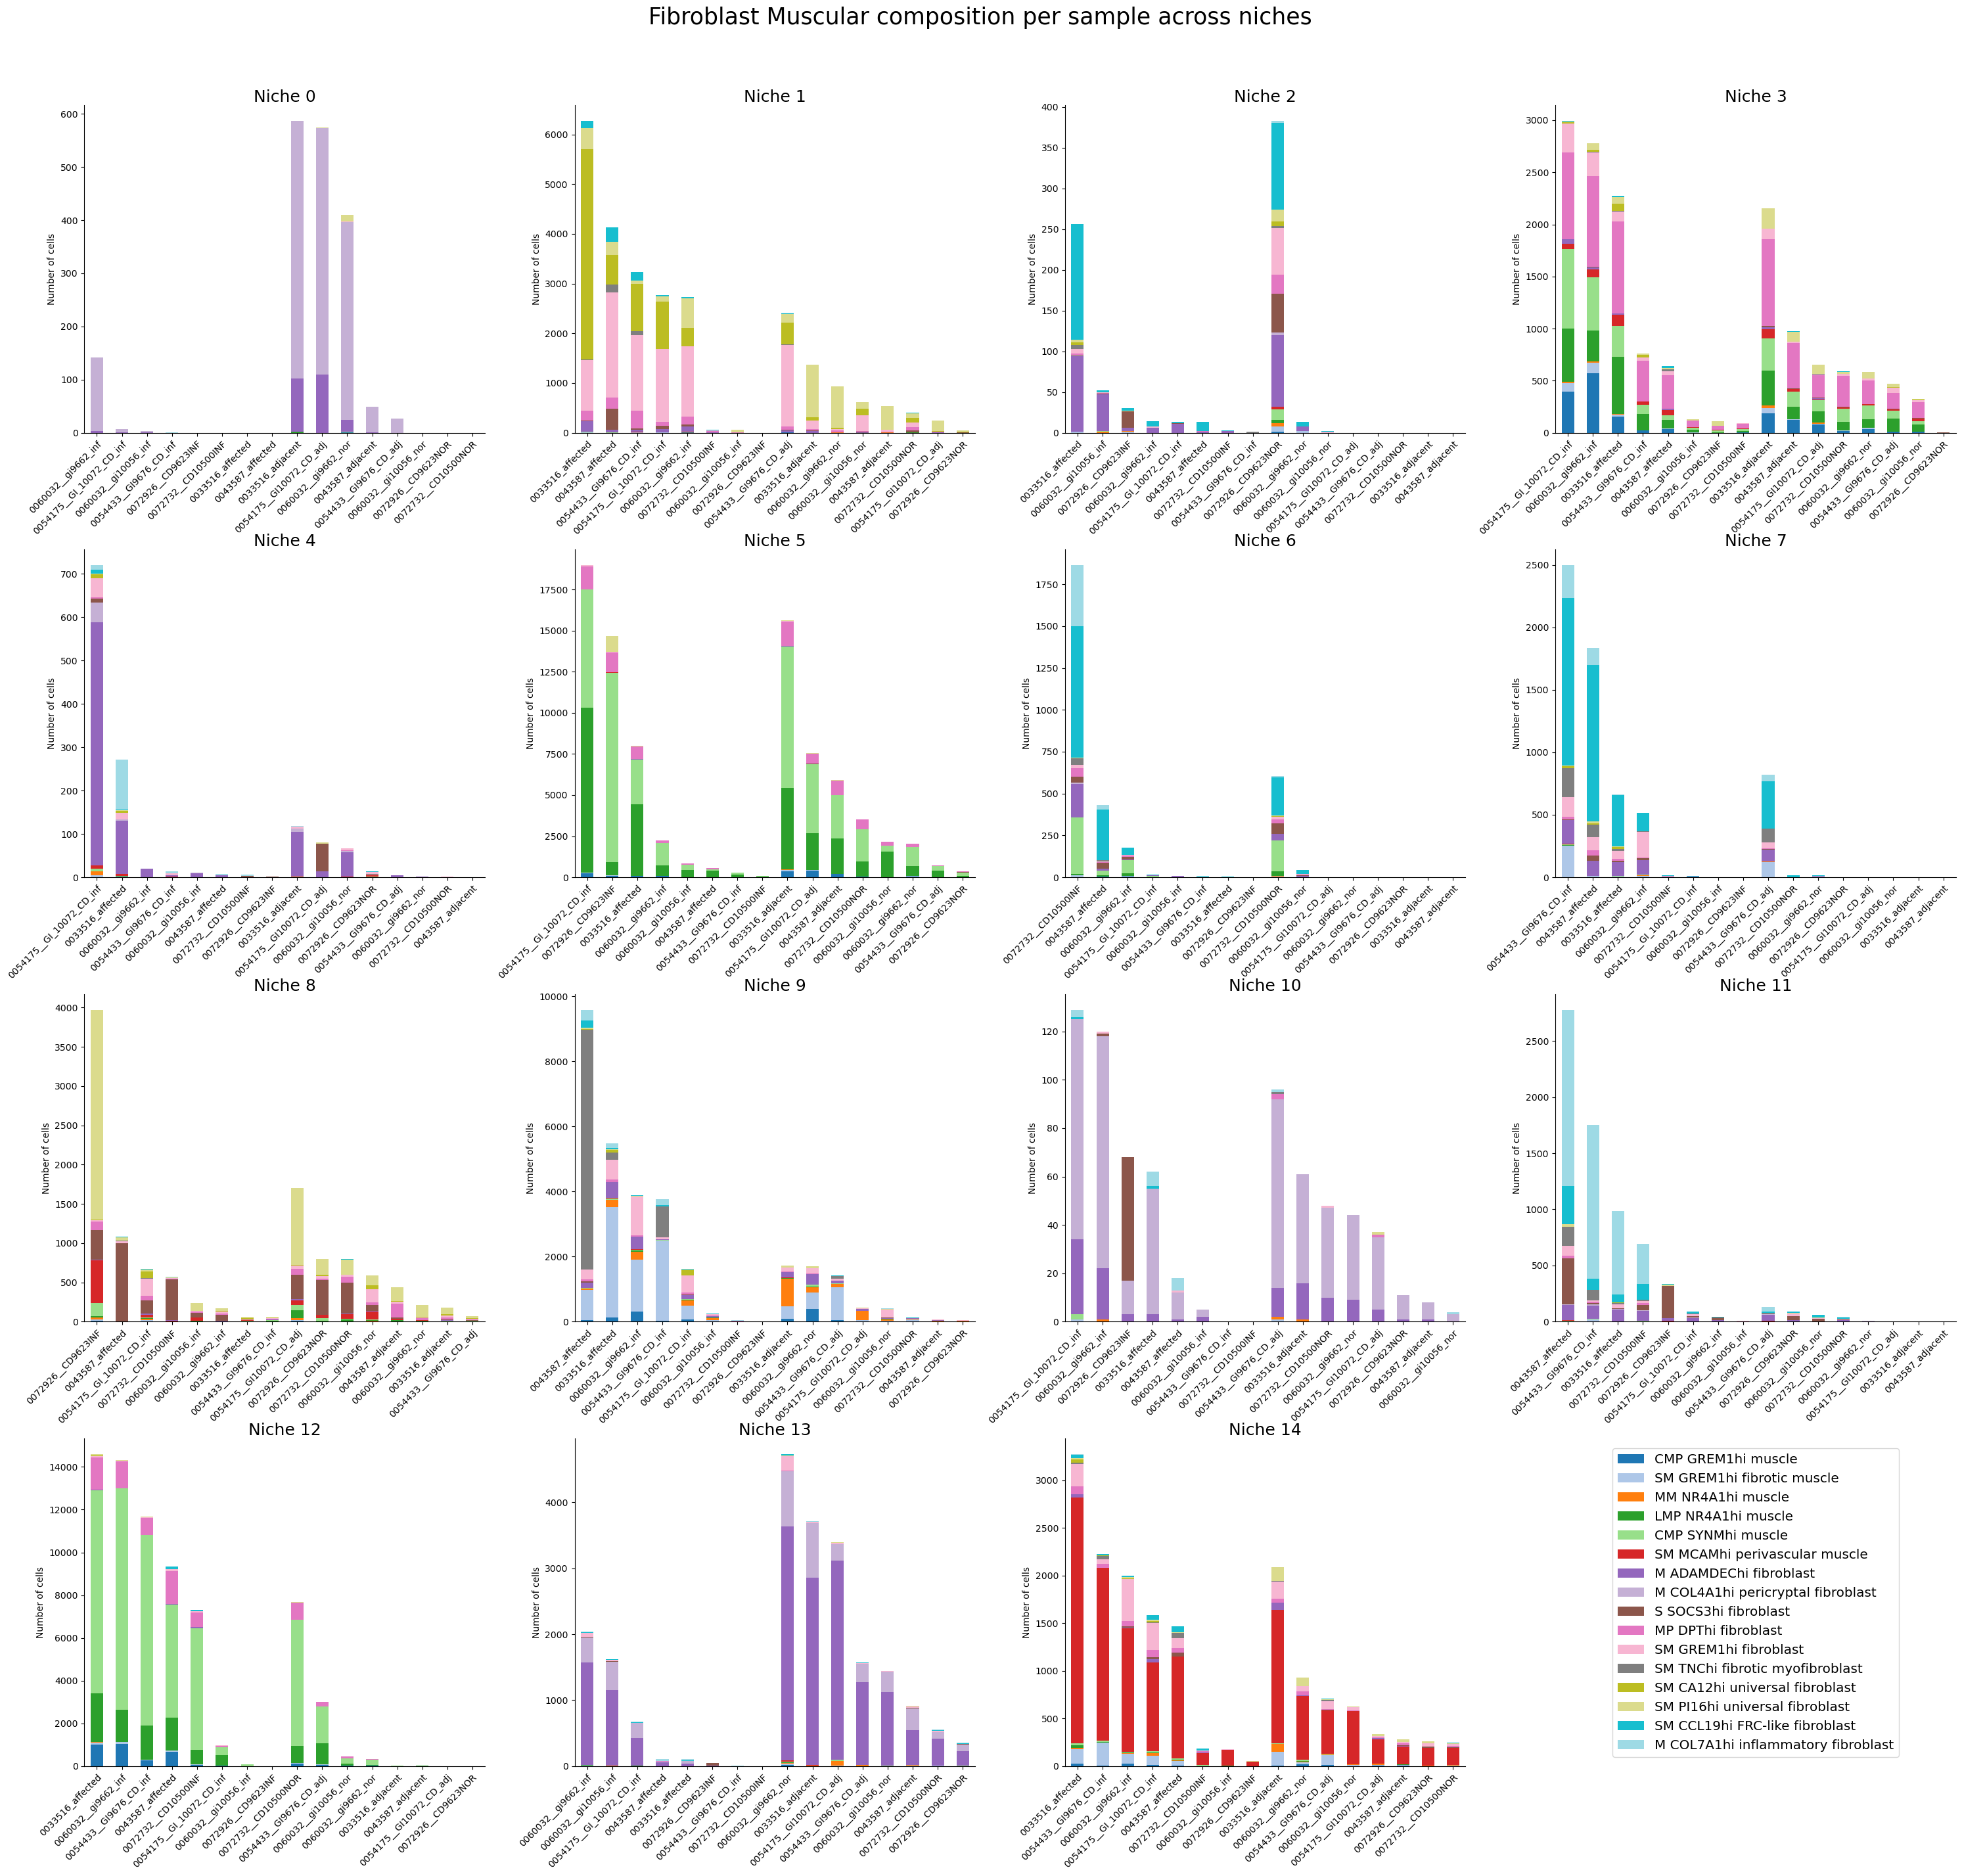

In [17]:
cell_order = ['CMP GREM1hi muscle', 'SM GREM1hi fibrotic muscle', 'MM NR4A1hi muscle', 
                'LMP NR4A1hi muscle', 'CMP SYNMhi muscle','SM MCAMhi perivascular muscle',
            'M ADAMDEChi fibroblast', 'M COL4A1hi pericryptal fibroblast', 'S SOCS3hi fibroblast', 
            'MP DPThi fibroblast', 'SM GREM1hi fibroblast','SM TNChi fibrotic myofibroblast', 
            'SM CA12hi universal fibroblast', 'SM PI16hi universal fibroblast', 'SM CCL19hi FRC-like fibroblast', 'M COL7A1hi inflammatory fibroblast']

subplots_celltypes(["Fibroblast","Muscular"], cell_order=cell_order)

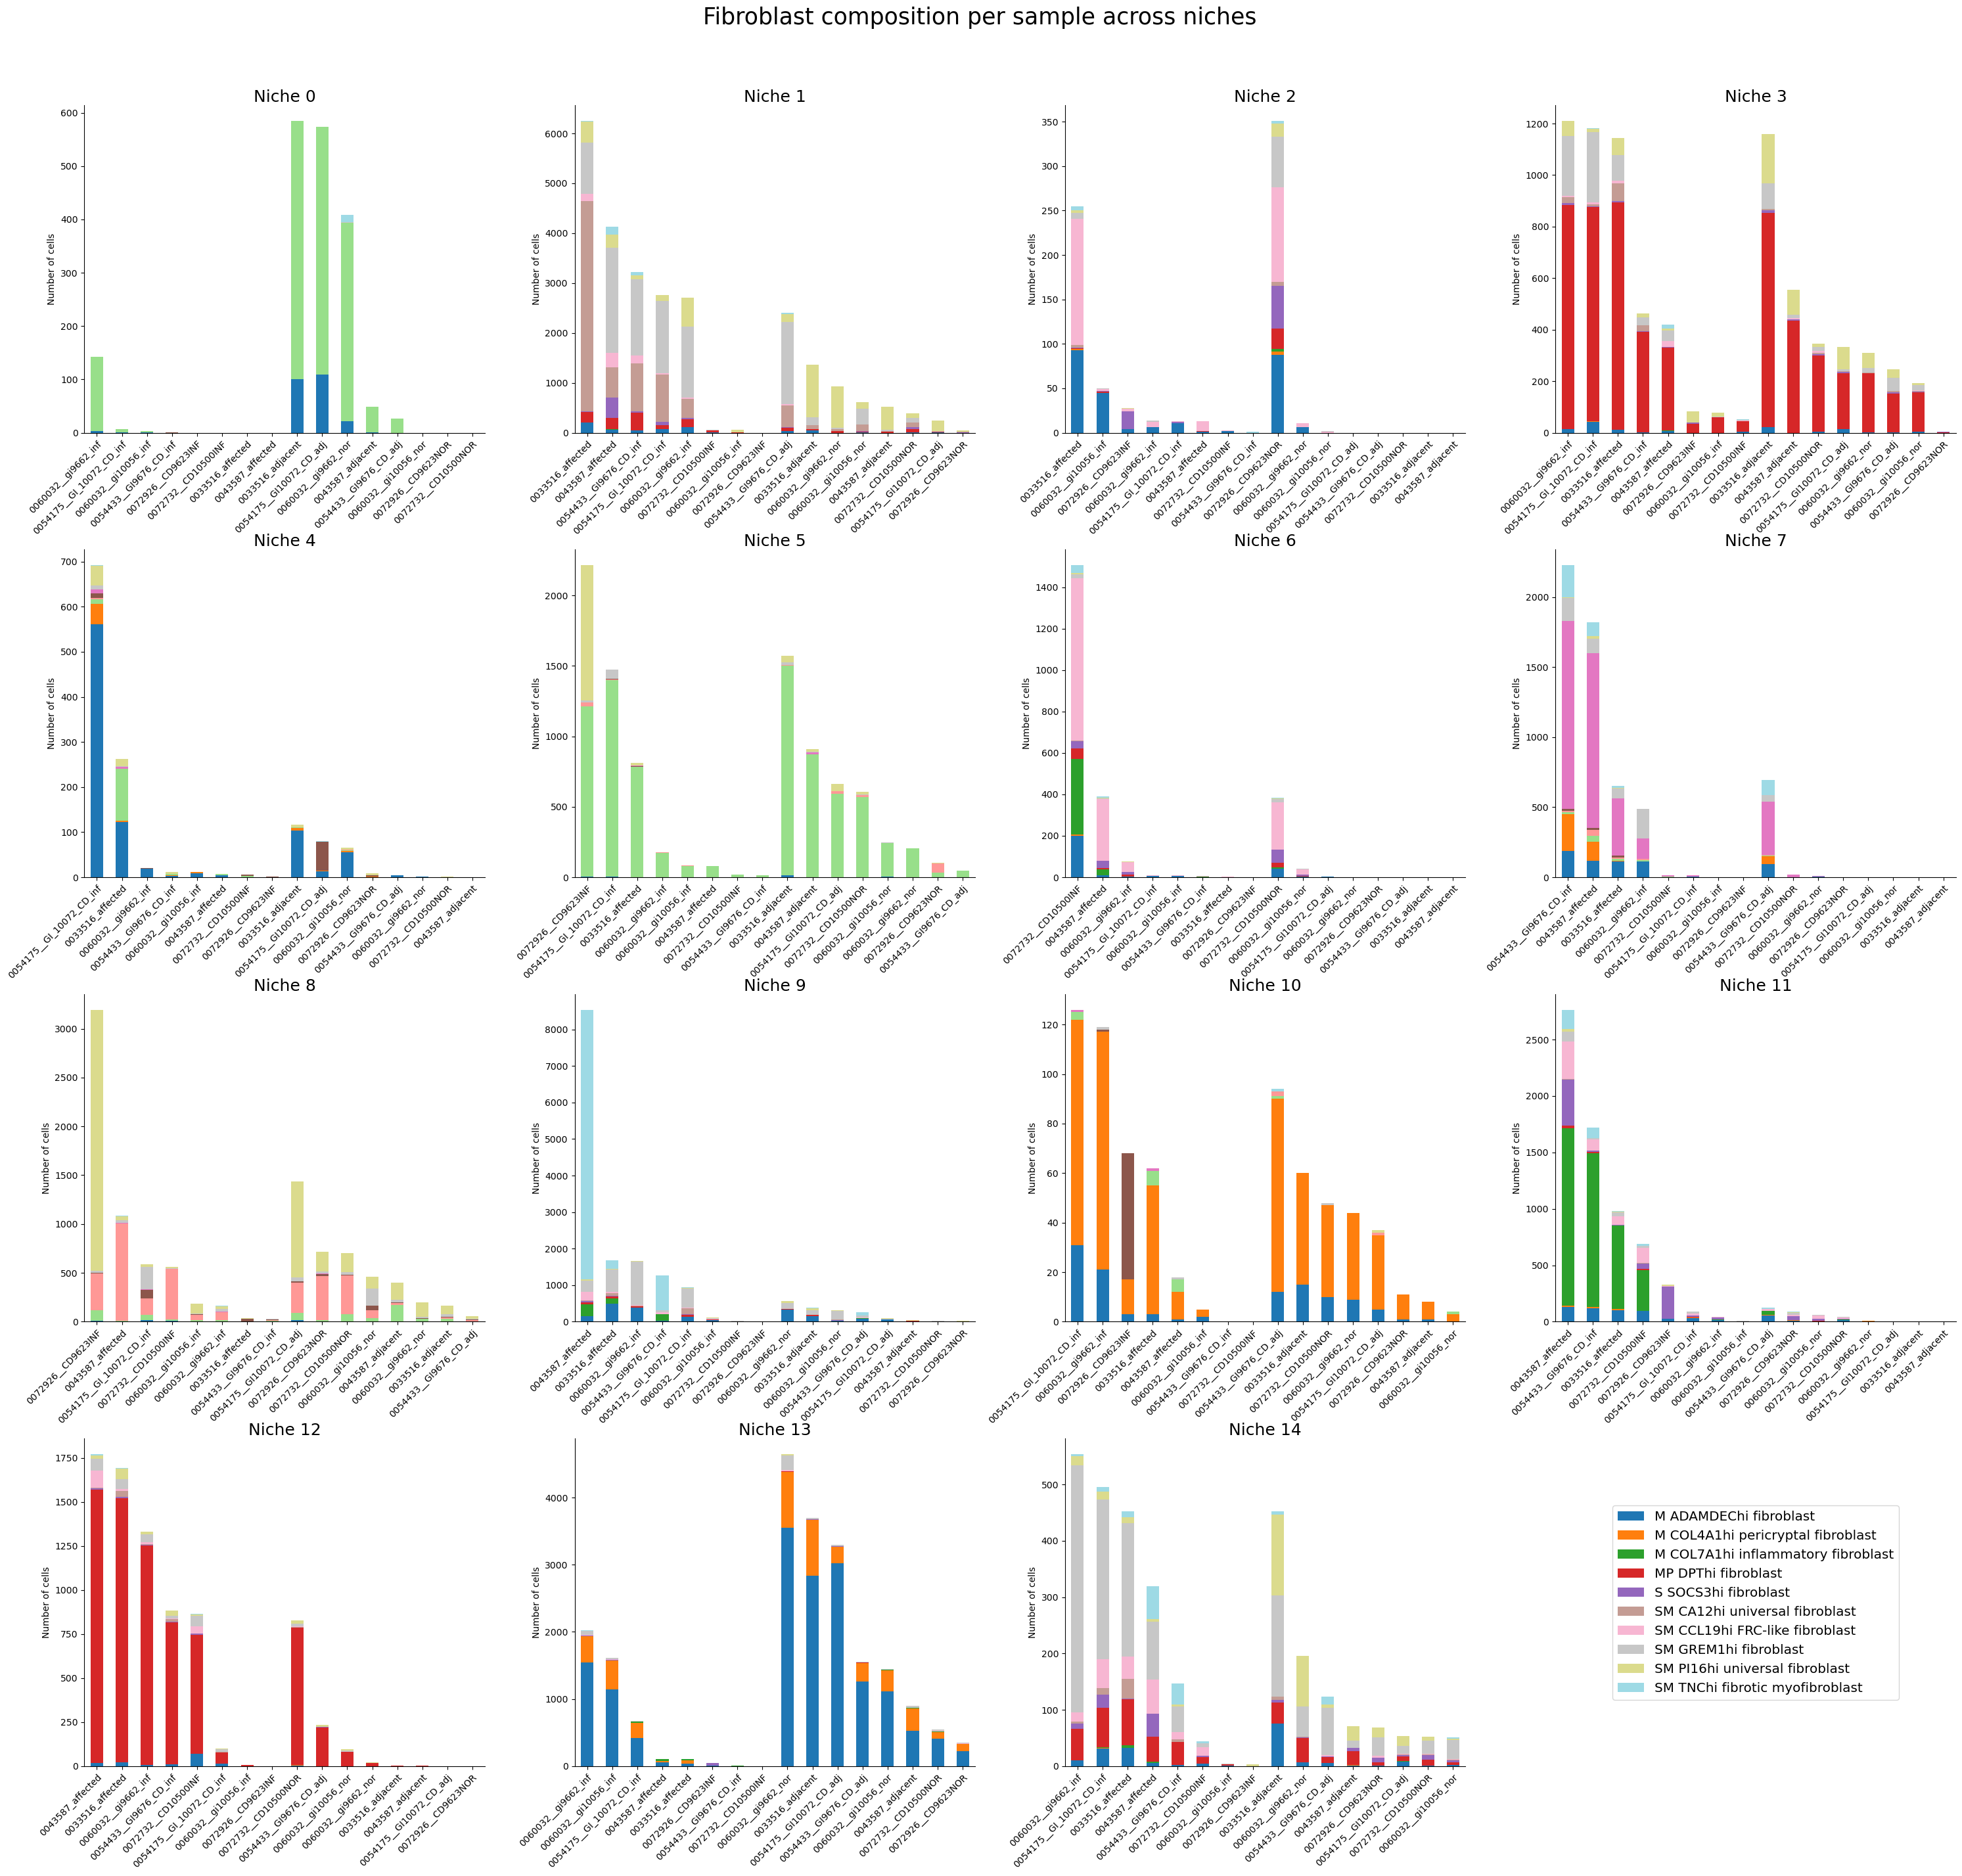

In [18]:
subplots_celltypes(["Fibroblast"])

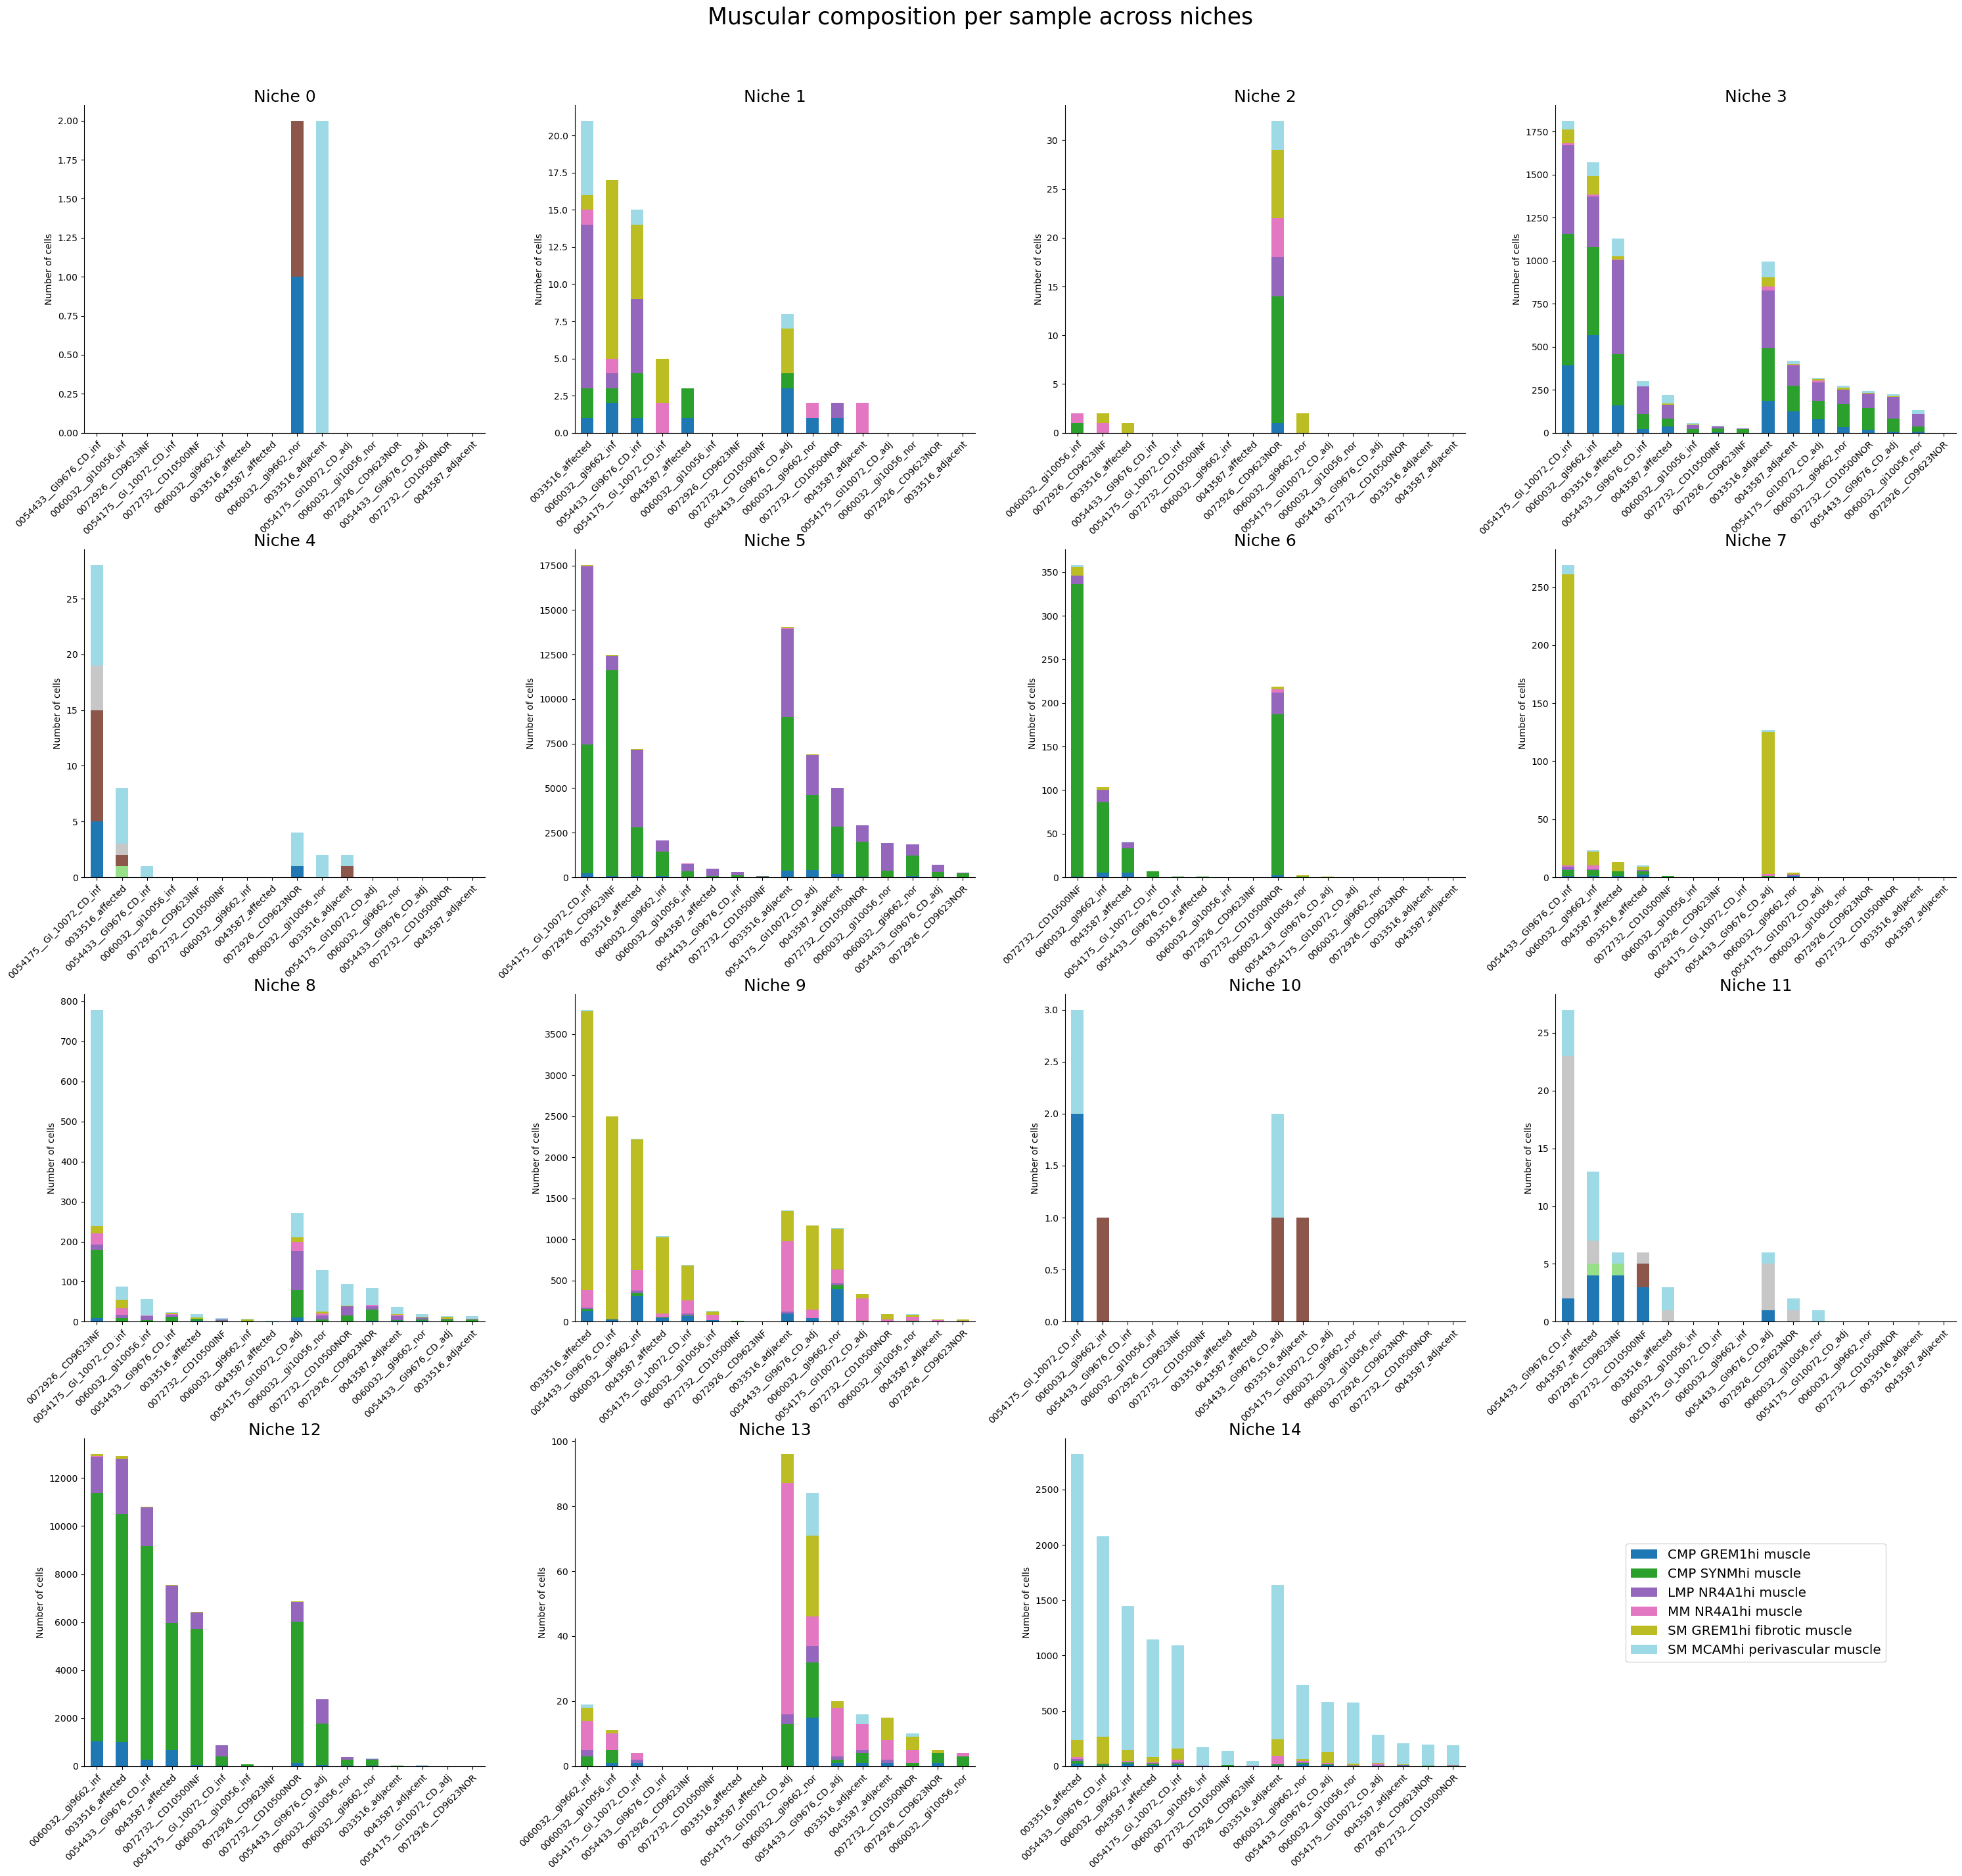

In [19]:
subplots_celltypes(["Muscular"])

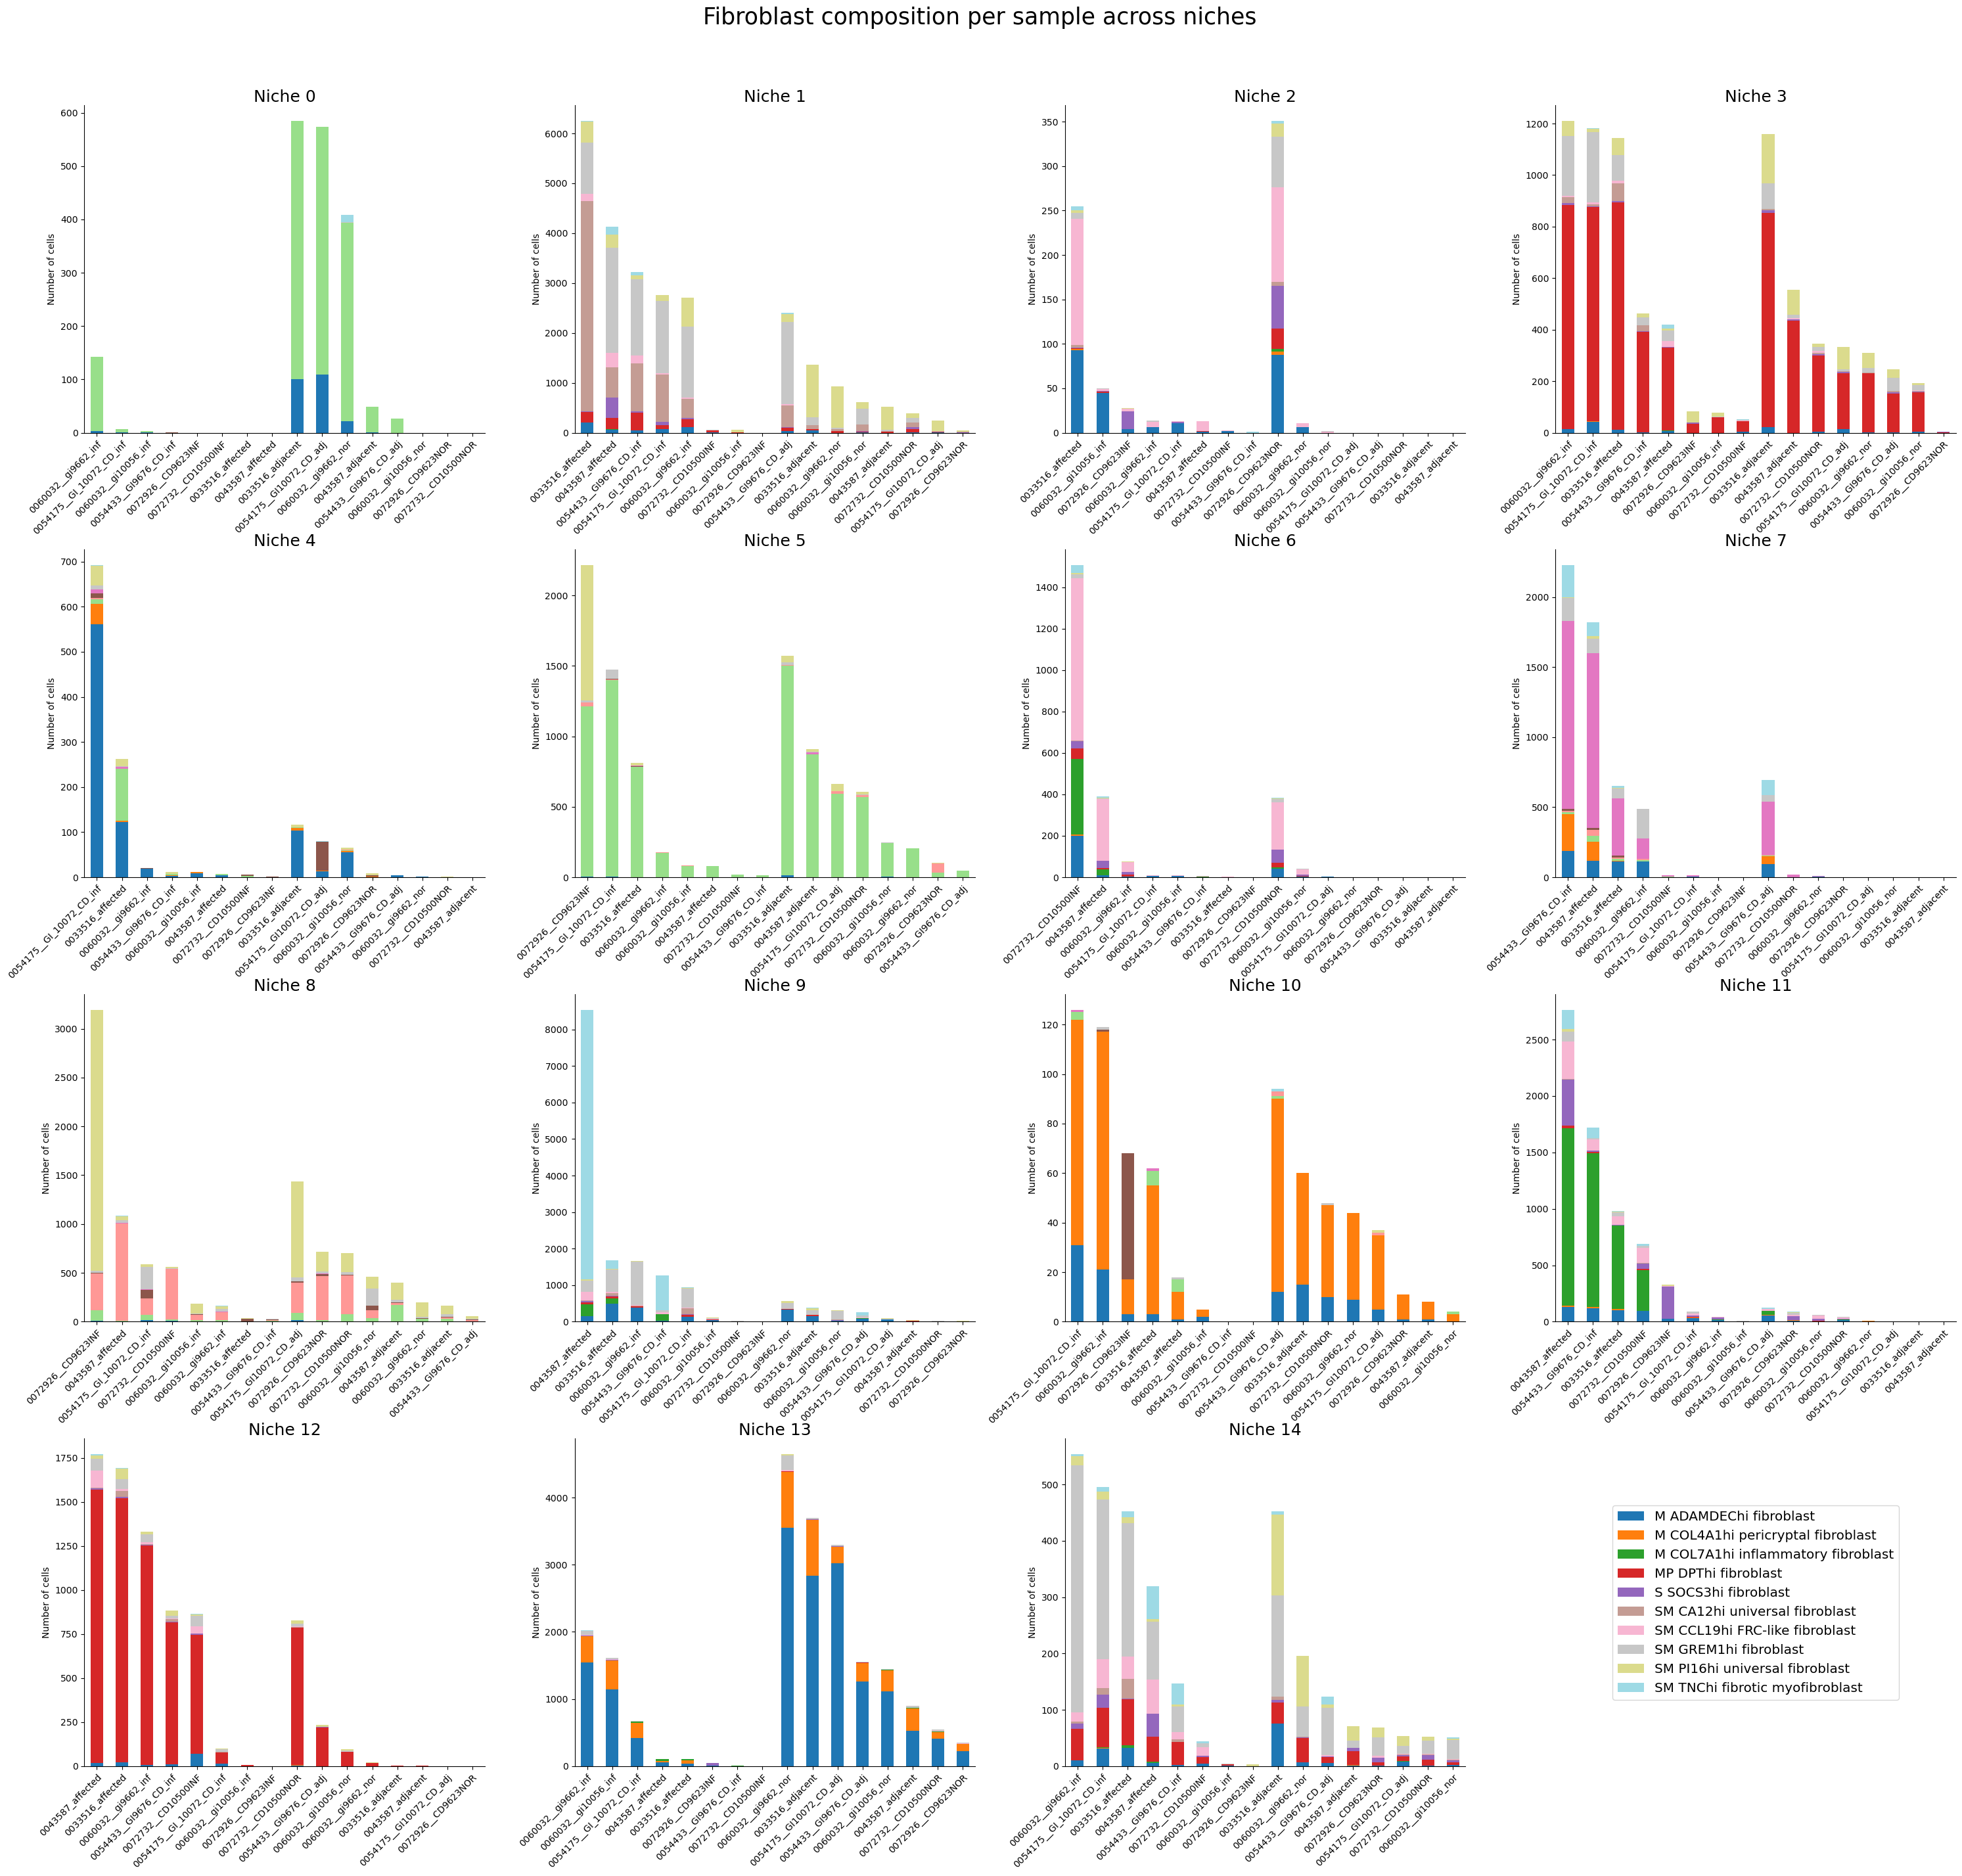

In [20]:
subplots_celltypes(["Fibroblast"])

# Niche 9, affected samples, fibroblasts

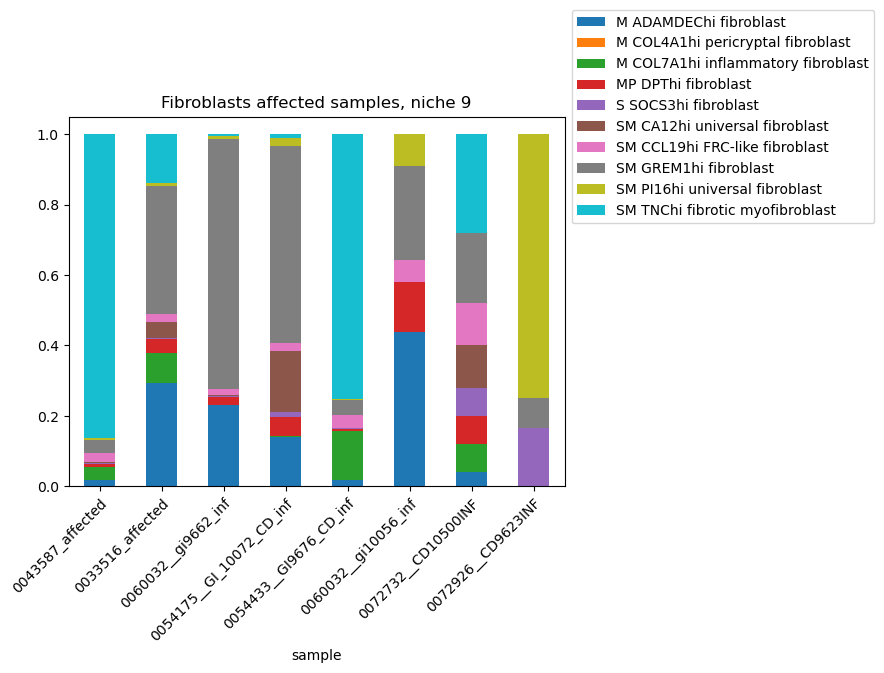

In [21]:
niche = 9
compartment = sample_niche_celltype_compartment[sample_niche_celltype_compartment["compartment_sub"]== "Fibroblast"]

dataframe = get_niche(compartment, niche)
sample = dataframe["sample"].values
celltype = dataframe["annot_new"].values

cross = pd.crosstab(sample, celltype, rownames =["sample"], colnames=["annot_new"], normalize = "index") 
cross = cross.drop(['0033516_adjacent', '0043587_adjacent','0054175__GI10072_CD_adj', '0054433__GI9676_CD_adj', '0060032__gi9662_nor', '0060032__gi10056_nor', 
       '0072732__CD10500NOR', '0072926__CD9623NOR'],axis=0)

cross = cross.reindex(['0043587_affected','0033516_affected','0060032__gi9662_inf','0054175__GI_10072_CD_inf','0054433__GI9676_CD_inf','0060032__gi10056_inf','0072732__CD10500INF','0072926__CD9623INF'])

barplot = cross.plot(kind="bar", stacked=True, legend = True)
labels = barplot.get_xticklabels()
plt.setp(labels, rotation=45, rotation_mode='anchor', ha='right', va='top')
barplot.legend(loc="center left", bbox_to_anchor=(1, 1))
barplot.set_title(f"Fibroblasts affected samples, niche {niche}")
barplot.get_figure().savefig(f"{path}{barplot.get_title()}",bbox_inches = "tight")


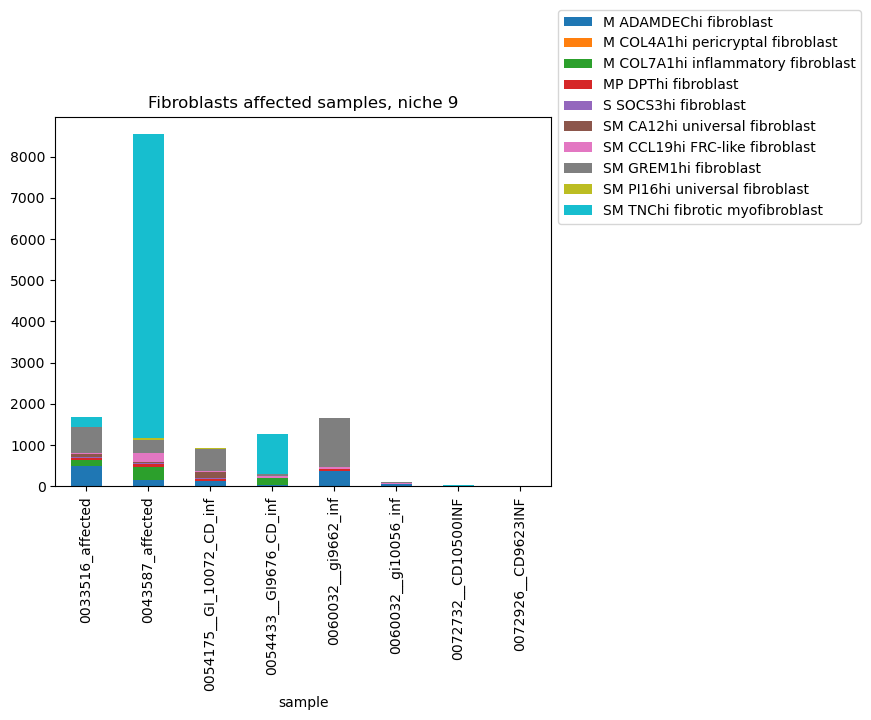

In [22]:
niche = 9
compartment = sample_niche_celltype_compartment[sample_niche_celltype_compartment["compartment_sub"]== "Fibroblast"]

dataframe = get_niche(compartment, niche)
sample = dataframe["sample"].values
celltype = dataframe["annot_new"].values

cross = pd.crosstab(sample, celltype, rownames =["sample"], colnames=["annot_new"]) #, normalize = "index"

cross

cross = cross.drop(['0033516_adjacent', '0043587_adjacent','0054175__GI10072_CD_adj', '0054433__GI9676_CD_adj', '0060032__gi9662_nor', '0060032__gi10056_nor', 
       '0072732__CD10500NOR', '0072926__CD9623NOR'],axis=0)

cross

barplot = cross.plot(kind="bar", stacked=True, legend = True)
barplot.legend(loc="center left", bbox_to_anchor=(1, 1))
barplot.set_title(f"Fibroblasts affected samples, niche {niche}")
barplot.get_figure().savefig(f"{path}{barplot.get_title()}_notnorm",bbox_inches = "tight")
